<a href="https://colab.research.google.com/github/vneumannufprbr/TrabajosenPython/blob/main/SenPredicSTGRUPresaOk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predicciones con Red Neuronal Recorrente GRU

In [20]:
# 0. Fijar semillas aleatorias para reproducibilidad
import os
import random
import numpy as np
import tensorflow as tf

def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Para versiones más recientes de TensorFlow, es posible que también necesites:
    # tf.keras.utils.set_random_seed(seed)

set_all_seeds()

# 1. Instalación de librerías
!pip install keras-tuner -q

# 2. Importación de las librerías necesarias
import pandas as pd
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import keras_tuner as kt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 3. Carga y preparación de los datos
try:
    df = pd.read_excel('datos_fusionados_operantes.xlsx')
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'datos_fusionados_operantes.xlsx' se haya cargado en tu entorno de Colab.")
    df = pd.DataFrame()

if not df.empty:
    # Seleccionamos el sensor para el ejemplo
    sensor_tag = 'PS-E-023/2 | (MCA)'
    df_sensor = df[df['nombre_etiqueta'] == sensor_tag].copy()

    # Comprobar si df_sensor está vacío
    if df_sensor.empty:
        print(f"Error: No se encontraron datos para la etiqueta de sensor '{sensor_tag}'. Por favor, verifica la etiqueta del sensor y los datos.")
    else:
        df_sensor['fecha'] = pd.to_datetime(df_sensor['fecha'])
        df_sensor = df_sensor.sort_values('fecha').set_index('fecha')

        # 4. Escalado de datos
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(df_sensor[['valor_promedio']])

        # Comprobar si hay valores NaN o infinitos en los datos escalados
        if np.isnan(scaled_data).any() or np.isinf(scaled_data).any():
            print("Error: Los datos escalados contienen valores NaN o infinitos. Por favor, verifica tus datos y el proceso de escalado.")
        else:
             print("Datos cargados, preparados y escalados exitosamente.")
else:
    print("El DataFrame df está vacío. No se pudo cargar el archivo.")

Datos cargados, preparados y escalados exitosamente.


<Figure size 1200x600 with 0 Axes>

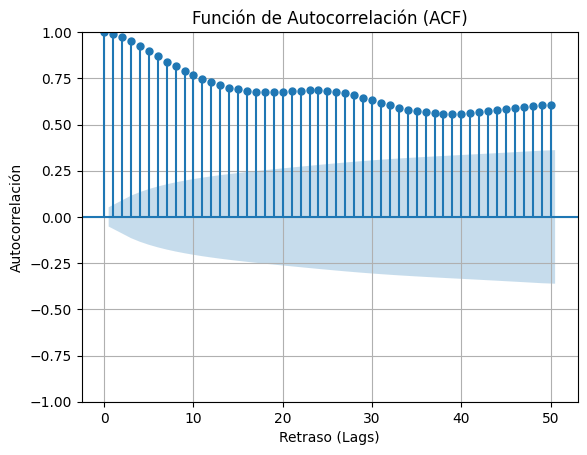


--- Análisis de ACF ---
Observa el gráfico de ACF para identificar el punto donde la autocorrelación decae significativamente.
Este punto puede sugerir un tamaño de ventana deslizante (sequence_length) apropiado para el modelo GRU.


In [21]:
# Análisis de la Función de Autocorrelación (ACF) para estimar la ventana deslizante
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Seleccionamos la serie de tiempo a analizar (la columna 'valor_promedio' del sensor seleccionado)
# Asegúrate de que df_sensor esté disponible y no esté vacío antes de ejecutar esto
if not df_sensor.empty:
    time_series_data = df_sensor['valor_promedio'].dropna() # Eliminar NaNs si los hay

    # Trazar la función de autocorrelación
    plt.figure(figsize=(12, 6))
    plot_acf(time_series_data, lags=50) # Puedes ajustar 'lags' según la longitud de tu serie
    plt.title('Función de Autocorrelación (ACF)')
    plt.xlabel('Retraso (Lags)')
    plt.ylabel('Autocorrelación')
    plt.grid(True)
    plt.show()

    print("\n--- Análisis de ACF ---")
    print("Observa el gráfico de ACF para identificar el punto donde la autocorrelación decae significativamente.")
    print("Este punto puede sugerir un tamaño de ventana deslizante (sequence_length) apropiado para el modelo GRU.")
else:
    print("El DataFrame df_sensor está vacío. No se puede realizar el análisis de ACF.")

In [33]:
# Definir el valor de sequence_length basado en el análisis de ACF
sequence_length = 20

# 5. Función para crear secuencias
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        y.append(data[i + sequence_length, 0]) # Añadir el valor de la única característica
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)

# Comprobar si hay valores NaN o infinitos en las secuencias generadas (X e y)
if np.isnan(X).any() or np.isinf(X).any():
     print("Error: Las secuencias generadas (X) contienen valores NaN o infinitos. Por favor, verifica tus datos.")
elif np.isnan(y).any() or np.isinf(y).any():
     print("Error: Las secuencias generadas (y) contienen valores NaN o infinitos. Por favor, verifica tus datos.")
else:
    # Reshape de X para que sea compatible con la capa GRU [muestras, timesteps, features]
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # 6. División de datos (cronológica)
    split_point = int(len(X) * 0.8)
    X_train, X_test = X[:split_point], X[split_point:]
    y_train, y_test = y[:split_point], y[split_point:]

    # Comprobar si hay valores NaN o infinitos en los conjuntos de entrenamiento/prueba
    if np.isnan(X_train).any() or np.isinf(X_train).any() or \
       np.isnan(X_test).any() or np.isinf(X_test).any() or \
       np.isnan(y_train).any() or np.isinf(y_train).any() or \
       np.isnan(y_test).any() or np.isinf(y_test).any():
        print("Error: Los conjuntos de entrenamiento o prueba contienen valores NaN o infinitos. Por favor, verifica tus datos.")
    else:
        # 7. Construcción del modelo para KerasTuner
        def build_model(hp):
            model = Sequential()
            model.add(GRU(
                units=hp.Int('units_gru', min_value=16, max_value=64, step=16),
                return_sequences=False,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ))
            model.add(Dropout(rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
            model.add(Dense(1)) # Capa de salida

            model.compile(
                optimizer=keras.optimizers.Adam(
                    hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5]), # Rango de tasa de aprendizaje reducido
                    clipnorm=1.0
                ),
                loss='mean_squared_error'
            )
            return model

        # 8. Configuración del autoajuste (Tuner)
        tuner = kt.Hyperband(
            build_model,
            objective='val_loss',
            max_epochs=50,
            factor=3,
            directory='keras_tuner_dir',
            project_name='gru_sensor_tuning'
        )

        print("--- Iniciando búsqueda de hiperparámetros ---")
        stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
        tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[stop_early], verbose=2)

        # 9. Obtener el mejor modelo y entrenarlo
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        print(f"\n--- Mejores hiperparámetros encontrados ---")
        print(f"Unidades GRU: {best_hps.get('units_gru')}") # Cambiado nombre del hiperparámetro
        print(f"Dropout: {best_hps.get('dropout')}")
        print(f"Tasa de aprendizaje: {best_hps.get('learning_rate')}")

        # Obtener el mejor modelo directamente del afinador
        model = tuner.get_best_models(num_models=1)[0]

        history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[stop_early], verbose=0)
        print("\n--- Modelo final entrenado ---")

Reloading Tuner from keras_tuner_dir/gru_sensor_tuning/tuner0.json
--- Iniciando búsqueda de hiperparámetros ---

--- Mejores hiperparámetros encontrados ---
Unidades GRU: 64
Dropout: 0.2
Tasa de aprendizaje: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras_tuner/src/tuners/hyperband.py:435: UserWarning: Model 'sequential' had a build config, but the model cannot be built automatically in `build_from_config(config)`. You should implement `def build_from_config(self, config)`, and you might also want to implement the method  that generates the config at saving time, `def get_build_config(self)`. The method `build_from_config()` is meant to create the state of the model (i.e. its variables) upon deserialization.
  model.build_from_config(
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the sav


--- Modelo final entrenado ---


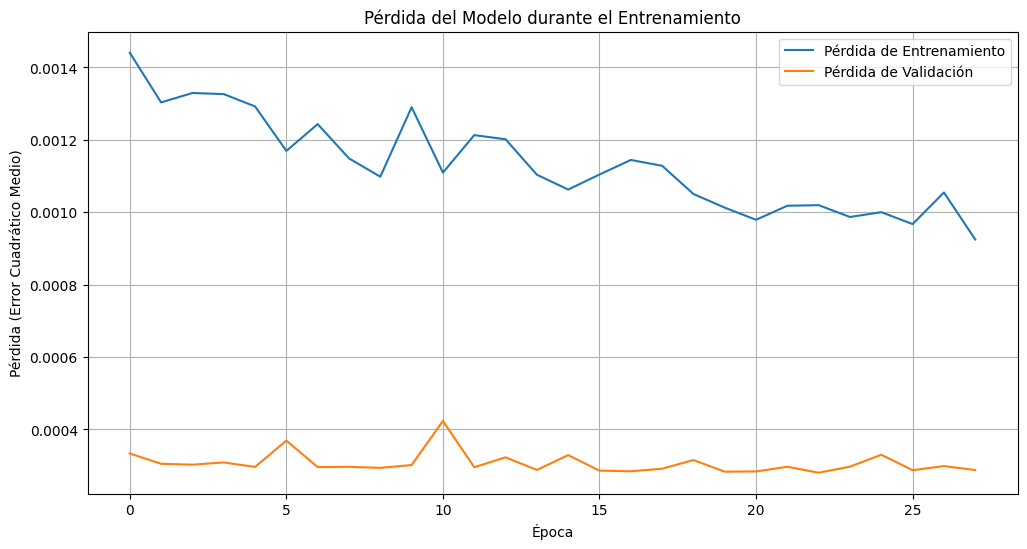

In [34]:
# 4. Visualizar la evolución de la función de pérdida
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida del Modelo durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (Error Cuadrático Medio)')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# 5. Realizar predicciones futuras
last_sequence = scaled_data[-sequence_length:]
last_sequence = np.reshape(last_sequence, (1, sequence_length, 1))

future_prediction_scaled = model.predict(last_sequence)
future_prediction = scaler.inverse_transform(future_prediction_scaled)

print(f"\n--- Predicción para el próximo período ---")
print(f"Valor predicho: {future_prediction[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step

--- Predicción para el próximo período ---
Valor predicho: 25.7980


In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# 6. Realizar y des-escalar las predicciones
predictions_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)) # Reshape y_test aquí

# 7. Calcular métricas de evaluación
mse = mean_squared_error(y_test_real, predictions)
rmse = sqrt(mse)
mae = mean_absolute_error(y_test_real, predictions)
r2 = r2_score(y_test_real, predictions)

print(f"Evaluación del Modelo GRU para el Sensor: {sensor_tag}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
Evaluación del Modelo GRU para el Sensor: PS-E-023/2 | (MCA)
MSE: 1.1837
RMSE: 1.0880
MAE: 0.6150
R2: 0.9258


In [37]:
# 8. Realizar predicciones futuras iterativamente

num_future_steps = 30  # Definir el número de pasos futuros a predecir (por ejemplo, 30 períodos)
future_predictions_scaled = []

# Comenzar con la última secuencia de los datos históricos escalados
current_sequence = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)

for _ in range(num_future_steps):
    # Predecir el siguiente paso
    next_prediction_scaled = model.predict(current_sequence)

    # Añadir la predicción a la lista
    future_predictions_scaled.append(next_prediction_scaled[0][0])

    # Actualizar la secuencia de entrada: eliminar el primer elemento y añadir la nueva predicción
    current_sequence = np.append(current_sequence[:, 1:, :], next_prediction_scaled.reshape(1, 1, 1), axis=1)

# Des-escalar las predicciones futuras escaladas
future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

print(f"\n--- Predicciones para los próximos {num_future_steps} períodos ---")
for i, pred in enumerate(future_predictions):
    print(f"Período {i+1}: {pred[0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

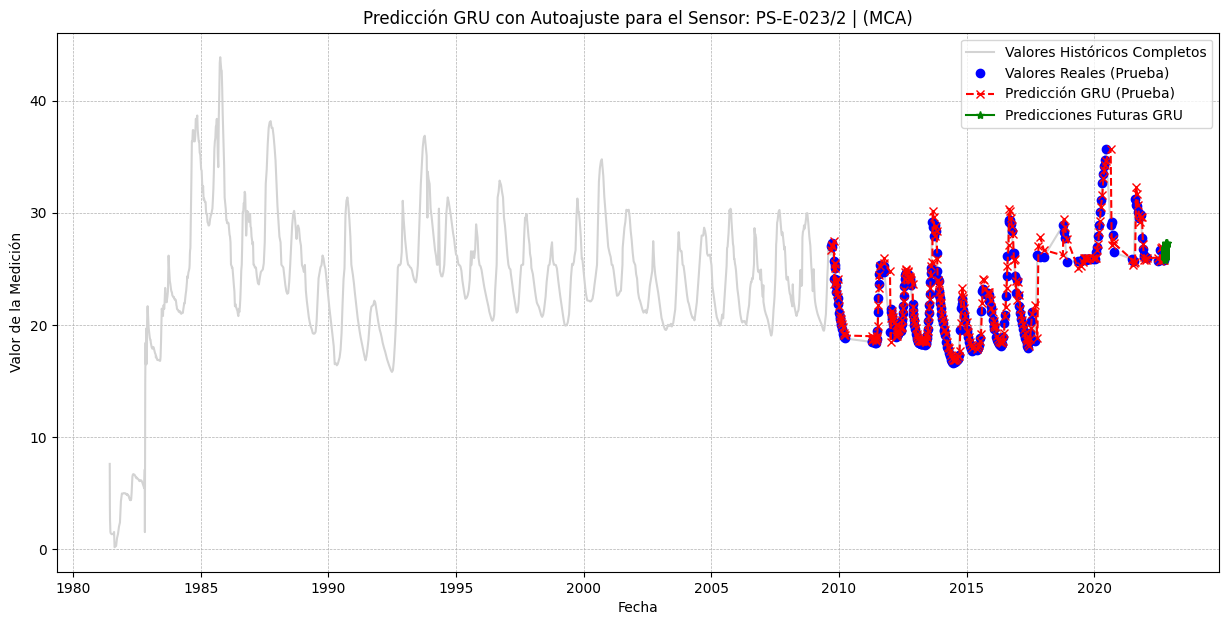

In [38]:
# 9. Visualización (Modificada para incluir predicciones futuras)

# Determinar las fechas para las predicciones futuras
# El conjunto de prueba comienza en el índice split_point de las secuencias (X, y)
# Necesitamos encontrar la fecha correspondiente en el índice original de df_sensor

# Calcular el índice en el df_sensor original que corresponde al inicio de las secuencias del conjunto de prueba
start_index_test_data = split_point + sequence_length

# Obtener las fechas para el conjunto de prueba del índice original de df_sensor
test_dates = df_sensor.index[start_index_test_data:]

# Determinar la fecha para el inicio de las predicciones futuras
last_historical_date = df_sensor.index[-1]
future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=num_future_steps, freq=df_sensor.index.freq)


plt.figure(figsize=(15, 7))
plt.plot(df_sensor.index, df_sensor['valor_promedio'], label='Valores Históricos Completos', color='lightgray')
plt.plot(test_dates, y_test_real, label='Valores Reales (Prueba)', color='blue', marker='o', linestyle='None')
plt.plot(test_dates, predictions, label='Predicción GRU (Prueba)', color='red', marker='x', linestyle='--') # Añadir predicciones futuras
plt.plot(future_dates, future_predictions, label='Predicciones Futuras GRU', color='green', marker='*', linestyle='-') # Añadir predicciones futuras

plt.title(f'Predicción GRU con Autoajuste para el Sensor: {sensor_tag}')
plt.xlabel('Fecha')
plt.ylabel('Valor de la Medición')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [39]:
# 10. Guardar el modelo entrenado
model_save_path = 'gru_sensor_model.h5'
model.save(model_save_path)

print(f"\n--- Modelo guardado exitosamente ---")
print(f"Ruta del archivo: {model_save_path}")


--- Modelo guardado exitosamente ---
Ruta del archivo: gru_sensor_model.h5


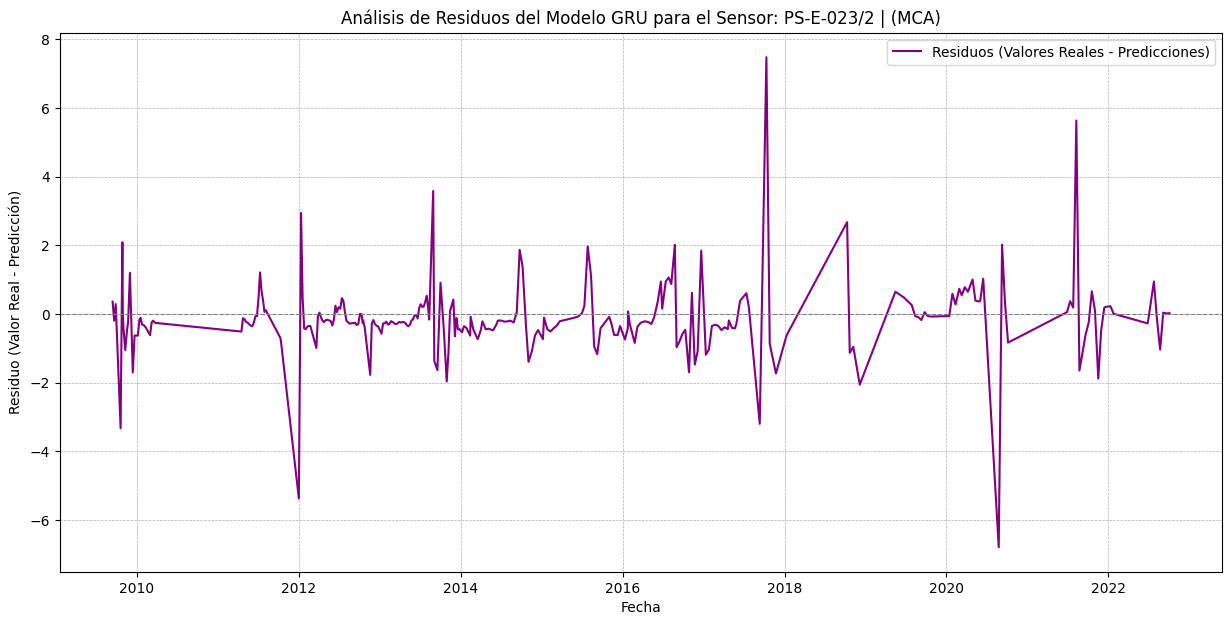

In [40]:
# Calcular residuos
residuals = y_test_real - predictions

# 11. Visualización de residuos
plt.figure(figsize=(15, 7))
plt.plot(test_dates, residuals, label='Residuos (Valores Reales - Predicciones)', color='purple')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Añadir una línea horizontal en cero

plt.title(f'Análisis de Residuos del Modelo GRU para el Sensor: {sensor_tag}') # Cambiado el título para reflejar GRU
plt.xlabel('Fecha')
plt.ylabel('Residuo (Valor Real - Predicción)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [41]:
# 12. Identificar fechas con los residuos positivos y negativos más grandes (Top 10)

# Obtener los índices de los residuos positivos más grandes (orden descendente)
top_10_positive_indices = np.argsort(residuals.flatten())[::-1][:10]

# Obtener los índices de los residuos negativos más grandes (orden ascendente)
top_10_negative_indices = np.argsort(residuals.flatten())[:10]

print(f"\n--- Fechas con los 10 Residuos Positivos Más Grandes ---")
for i in top_10_positive_indices:
    date_positive = test_dates[i]
    value_positive = residuals[i][0]
    print(f"Fecha: {date_positive.strftime('%Y-%m-%d')} (Residuo: {value_positive:.4f})")

print(f"\n--- Fechas con los 10 Residuos Negativos Más Grandes ---")
for i in top_10_negative_indices:
    date_negative = test_dates[i]
    value_negative = residuals[i][0]
    print(f"Fecha: {date_negative.strftime('%Y-%m-%d')} (Residuo: {value_negative:.4f})")


--- Fechas con los 10 Residuos Positivos Más Grandes ---
Fecha: 2017-10-11 (Residuo: 7.4787)
Fecha: 2021-08-09 (Residuo: 5.6348)
Fecha: 2013-08-30 (Residuo: 3.5838)
Fecha: 2012-01-12 (Residuo: 2.9453)
Fecha: 2018-10-10 (Residuo: 2.6740)
Fecha: 2009-10-28 (Residuo: 2.0870)
Fecha: 2020-09-08 (Residuo: 2.0179)
Fecha: 2016-08-24 (Residuo: 2.0126)
Fecha: 2015-07-28 (Residuo: 1.9658)
Fecha: 2014-09-24 (Residuo: 1.8667)

--- Fechas con los 10 Residuos Negativos Más Grandes ---
Fecha: 2020-08-24 (Residuo: -6.7961)
Fecha: 2012-01-02 (Residuo: -5.3774)
Fecha: 2009-10-20 (Residuo: -3.3296)
Fecha: 2017-09-11 (Residuo: -3.2009)
Fecha: 2018-12-06 (Residuo: -2.0602)
Fecha: 2013-10-30 (Residuo: -1.9687)
Fecha: 2021-11-16 (Residuo: -1.8844)
Fecha: 2012-11-19 (Residuo: -1.7744)
Fecha: 2017-11-23 (Residuo: -1.7319)
Fecha: 2009-12-14 (Residuo: -1.7052)


In [42]:
# 13. Identificar y guardar los 100 residuos más grandes (positivos y negativos) en un archivo Excel

# Obtener los índices de los 100 residuos positivos más grandes (orden descendente)
top_100_positive_indices = np.argsort(residuals.flatten())[::-1][:100]

# Obtener los índices de los 100 residuos negativos más grandes (orden ascendente)
top_100_negative_indices = np.argsort(residuals.flatten())[:100]

# Combinar los índices de los residuos positivos y negativos más grandes
all_top_100_indices = np.concatenate((top_100_positive_indices, top_100_negative_indices))

# Obtener las fechas y residuos correspondientes a los índices seleccionados
top_100_dates = test_dates[all_top_100_indices]
top_100_residuals = residuals[all_top_100_indices].flatten()

# Crear un DataFrame para almacenar las fechas y residuos
residuals_df = pd.DataFrame({
    'Fecha': top_100_dates,
    'Residuo': top_100_residuals
})

# Ordenar el DataFrame por el valor absoluto del residuo en orden descendente
residuals_df['Abs_Residuo'] = np.abs(residuals_df['Residuo'])
residuals_df = residuals_df.sort_values(by='Abs_Residuo', ascending=False).drop(columns='Abs_Residuo')

# Especificar la ruta y el nombre del archivo Excel
excel_file_path = 'top_100_residuos_GRU.xlsx'

# Guardar el DataFrame en un archivo Excel
try:
    residuals_df.to_excel(excel_file_path, index=False)
    print(f"\n--- Top 100 Residuos guardados exitosamente ---")
    print(f"Ruta del archivo: {excel_file_path}")
except Exception as e:
    print(f"Error al guardar el archivo Excel: {e}")


--- Top 100 Residuos guardados exitosamente ---
Ruta del archivo: top_100_residuos_GRU.xlsx
